In [1]:
import numpy as np
import matplotlib.pyplot as plt

# чтобы графики рисовались прямо в ноутбуке
%matplotlib inline


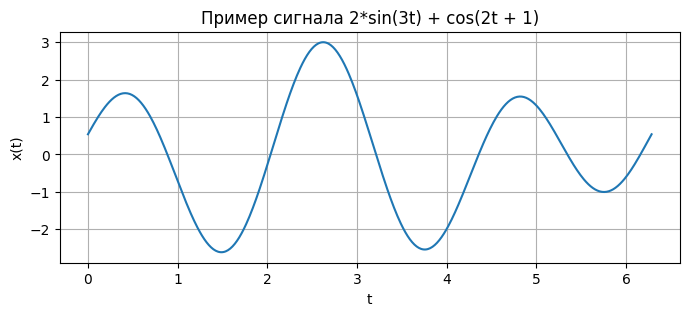

In [2]:
# создаём ось времени
t = np.linspace(0, 2*np.pi, 500)

# простой сигнал
x = 2 * np.sin(3*t) + np.cos(2*t + 1)

plt.figure(figsize=(8, 3))
plt.plot(t, x)
plt.title("Пример сигнала 2*sin(3t) + cos(2t + 1)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()


In [3]:
import pywt

wavelet_name = "haar"

# Один уровень дискретного вейвлет-преобразования
cA, cD = pywt.dwt(x, wavelet_name)  # Approximation и Detail [web:30][web:108]

len(x), len(cA), len(cD)


(500, 250, 250)

In [4]:
# Восстанавливаем сигнал только из аппроксимации (обнуляем детали)
x_approx = pywt.idwt(cA, None, wavelet_name)  # [web:30][web:108]

# Восстанавливаем сигнал только из деталей (обнуляем аппроксимацию)
x_detail = pywt.idwt(None, cD, wavelet_name)

# Подрежем до длины исходного сигнала (из-за округлений длина может отличаться на 1)
min_len = min(len(x), len(x_approx), len(x_detail))
x_cut = x[:min_len]
x_approx = x_approx[:min_len]
x_detail = x_detail[:min_len]
t_cut = t[:min_len]


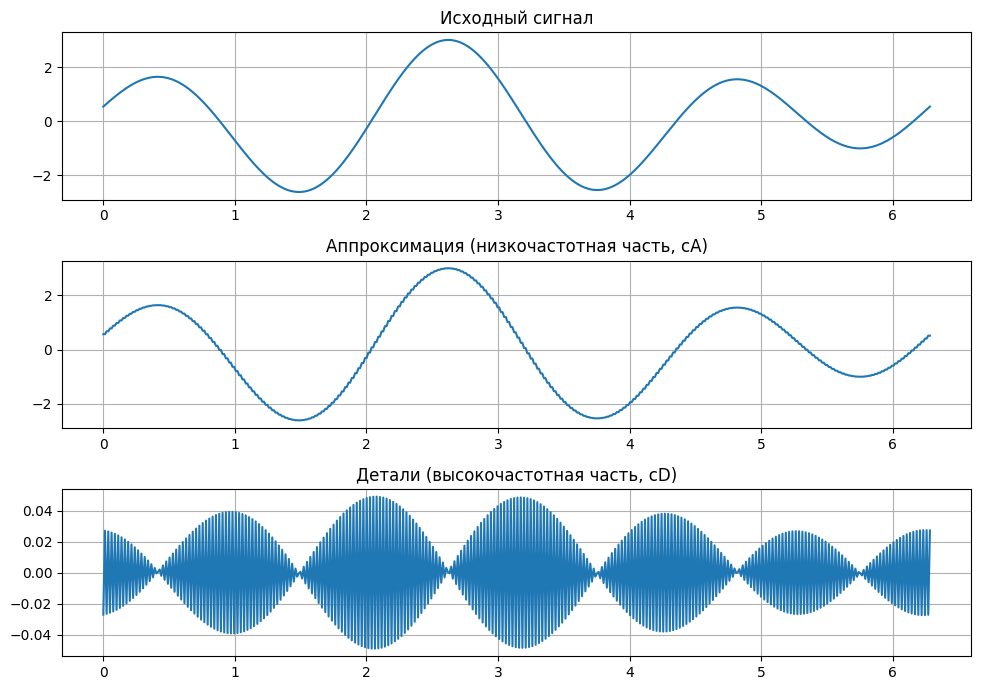

In [5]:
plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.plot(t_cut, x_cut)
plt.title("Исходный сигнал")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t_cut, x_approx)
plt.title("Аппроксимация (низкочастотная часть, cA)")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t_cut, x_detail)
plt.title("Детали (высокочастотная часть, cD)")
plt.grid(True)

plt.tight_layout()
plt.show()


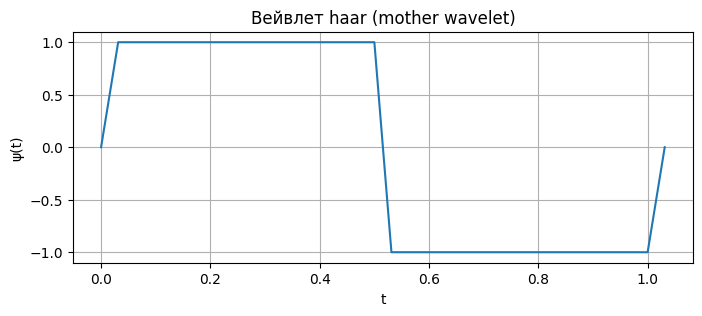

In [6]:
import pywt

wavelet = pywt.Wavelet("haar")  # можно потом поменять на "db4", "sym2" и т.п.
phi, psi, x = wavelet.wavefun(level=5)  # phi — масштабирующая, psi — вейвлет [web:101][web:108]

plt.figure(figsize=(8, 3))
plt.plot(x, psi)
plt.title(f"Вейвлет {wavelet.name} (mother wavelet)")
plt.xlabel("t")
plt.ylabel("ψ(t)")
plt.grid(True)
plt.show()


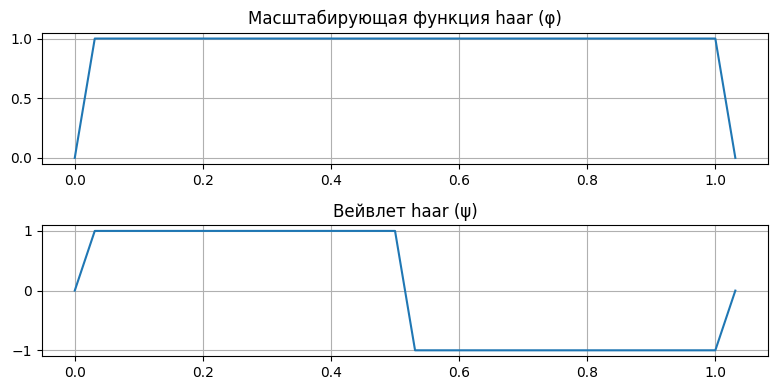

In [7]:
plt.figure(figsize=(8, 4))

plt.subplot(2, 1, 1)
plt.plot(x, phi)
plt.title(f"Масштабирующая функция {wavelet.name} (φ)")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(x, psi)
plt.title(f"Вейвлет {wavelet.name} (ψ)")
plt.grid(True)

plt.tight_layout()
plt.show()